In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Introduction 👀

This dataset represents video game sales from December 1971 to December 2024. It includes games for the majority of consoles, and for PC on different OS.

Unfortunately this dataset contains no digital sales (sad face). But... it is what it is.

But I have even more sad news for ya! No indie games! 🥲 So we will work with corp games. DAMN YOU ARASAKA!

As for columns. Well, I personally don't agree with namings like `console`, I think `platform` looks better. And as for rows, each row is a game per platform. Which means that the same game on PC and PS4 counts as separate games, so as two rows.

## Data inspection

Checking data structure

In [2]:
games = pd.read_csv("./data/vgchartz-2024.csv")
games.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


Newest and oldest games in data set

In [3]:
print(games["release_date"].min())
print(games["release_date"].max())

1971-12-03
2024-12-31


Basic data: shape, info and describe

In [4]:
print(f"Shape: \n{games.shape}")
print(30 * "-")
print(f"Info: \n{games.info()}")
print(30 * "-")
print(f"Description: \n{games.describe()}")

Shape: 
(64016, 14)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
dtypes: float64(6), str(8)
memory usage: 6.8 MB
Info: 
None
------------------------------
Description: 
       critic_score   total_sales      na_sales     jp_sal

Counting empty values per column

In [5]:
print(games.isnull().sum())

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


In [15]:
games.duplicated().sum()

np.int64(0)

### Checking weird data

Checking games with missing developer data

In [6]:
games[games["developer"].isnull()]

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
8486,/games/boxart/21030ccc.jpg,Gourmet Chef: Cook Your Way to Fame,DS,Misc,Ubisoft,NaN,NaN,0.14,0.13,NaN,NaN,0.01,2008-06-24,NaN
10832,/games/boxart/2426879ccc.jpg,Wordmaster,DS,Strategy,"Destination Software, Inc",NaN,NaN,0.09,0.09,NaN,0.0,0.01,2008-08-12,NaN
18185,/games/boxart/8436780ccc.jpg,SAS: Secure Tomorrow,PC,Shooter,City Interactive,NaN,NaN,0.00,NaN,NaN,0.0,0.00,2008-10-16,NaN
18455,/games/boxart/default.jpg,My Baby and Me,Wii,Misc,Unknown,NaN,NaN,0.00,NaN,NaN,0.0,NaN,NaN,NaN
19925,/games/boxart/default.jpg,Bounty Hunter,PC,Action,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999-11-30,NaN
25045,/games/boxart/default.jpg,Abandoner,PC,Adventure,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-09-17,NaN
27407,/games/boxart/full_7747476AmericaFrontccc.jpg,The Enchanted Unicorn,PC,Adventure,Take-Two Interactive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-09-16,NaN
31230,/games/boxart/full_8222233PALFrontccc.png,istanbul Beyleri,PC,Fighting,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-12-17,NaN
37057,/games/boxart/1105699ccc.jpg,Purrfect Pet Shop,PC,Misc,eGames,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-06-13,NaN
40753,/games/boxart/default.jpg,Duludubi Star,PC,Platform,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Checking empty sales and score

In [7]:
sales_cols = ["total_sales", "na_sales", "jp_sales", "pal_sales", "other_sales", "critic_score"]
games[games[sales_cols].isnull().all(axis=1)]

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
18922,/games/boxart/full_5741036AmericaFrontccc.jpg,God of War,Series,Action,Sony Interactive Entertainment,SIE Santa Monica Studio,NaN,NaN,NaN,NaN,NaN,NaN,2005-03-22,2020-03-04
18923,/games/boxart/full_3351915AmericaFrontccc.jpg,Warriors,Series,Action,KOEI,Omega Force,NaN,NaN,NaN,NaN,NaN,NaN,1997-06-30,2020-03-24
18924,/games/boxart/full_6662824AmericaFrontccc.png,Devil May Cry,Series,Action,Capcom,Capcom,NaN,NaN,NaN,NaN,NaN,NaN,2001-10-16,2020-02-03
18925,/games/boxart/full_8122622AmericaFrontccc.jpg,God of War (2018),All,Action,Sony Interactive Entertainment,SIE Santa Monica Studio,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-20,2022-11-23
18926,/games/boxart/full_6138740AmericaFrontccc.jpg,Dynasty Warriors,Series,Action,KOEI,Omega Force,NaN,NaN,NaN,NaN,NaN,NaN,1997-06-30,2020-03-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24


Checking missing total sales, when we have regional or other sales

In [ ]:
regional_cols = ["na_sales", "jp_sales", "pal_sales", "other_sales"]
games[games["total_sales"].isnull() & games[regional_cols].notna().any(axis=1)]

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update


### Conclusion

So! As we can see already we can make a top of highest scored games and bestsellers.
Also, we can see that we have gaps in data. It's fine for last updates because some game might not be updated after release. And that's fine for regional sales, because some games can be sold in specific regions only. But it's not okay when we don't have any data about sales in any region. Especially if there is no data about critic score either - `critic_score` is filled for only ~10% of rows (6,678 of 64,016), and `total_sales` for only ~30% (18,922). This will need to be addressed in cleaning.

## Data cleaning

Shape check

In [ ]:
games.shape

(64016, 14)

dropping `img` and `last_update`
Images brings no value for data analysis. And last update can be use only for showing the bases that has long dev support or a lot of bugs and fixes, who knows 🤷🏻‍♂️ 

In [ ]:
games = games.drop(columns=["img", "last_update"])

dropping rows where `total_sales` is null because it's pointless to keep that data for sales trends.

In [ ]:
games = games[games["total_sales"].notna()]

dropping series and all platforms, because those are aggregated row not individual games.

In [ ]:
games = games[~games["console"].isin(["Series", "All"])]

Extracting year from release date

In [ ]:
games["release_date"] = pd.to_datetime(games["release_date"], errors="coerce")
games["year"] = games["release_date"].dt.year.astype("Int64")

Add `decade` column

In [ ]:
games["decade"] = (games["year"] // 10 * 10).astype(str) + "s"

Renaming `console` to `platform` for clarity, since it includes PC.

In [ ]:
games = games.rename(columns={"console": "platform"})

Shape check #2

In [ ]:
games.shape

(18922, 14)

Rows removed

In [ ]:
print(f"Rows removed: {64016 - games.shape[0]}")

Rows removed: 45094


## Exploration

Checking which genre dominated sales in each decade

In [ ]:
top_genres = games.groupby("genre")["total_sales"].sum().nlargest(7).index
filtered = games[games["genre"].isin(top_genres)]

decade_genre = filtered.groupby(["decade", "genre"])["total_sales"].sum().reset_index()
decade_pivot = decade_genre.pivot(index="decade", columns="genre", values="total_sales").fillna(0)
decade_pct = decade_pivot.div(decade_pivot.sum(axis=1), axis=0) * 100


Data visualization

Text(95.72222222222221, 0.5, 'Genre')

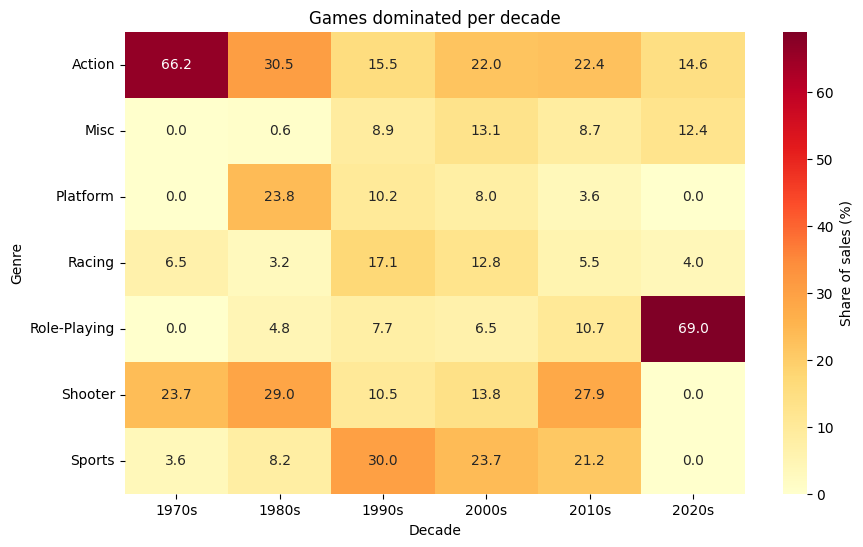

In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(decade_pct.T, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Share of sales (%)"})
ax.set_title("Games dominated per decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Genre")


So in 70s dominating genre was Action. in 80s shooters getting closer to it but actions still remained top 1. In 90s and 00s people preferred sport games. Shooters made a comeback in 10s. But in 20s Role Play dominated in sales. 

How did absolute sales of top genres evolve every year

In [ ]:
filtered_games = games[games["genre"].isin(top_genres)]
year_genre = filtered_games.groupby(["year", "genre"])["total_sales"].sum().unstack(fill_value=0)

Data visualization

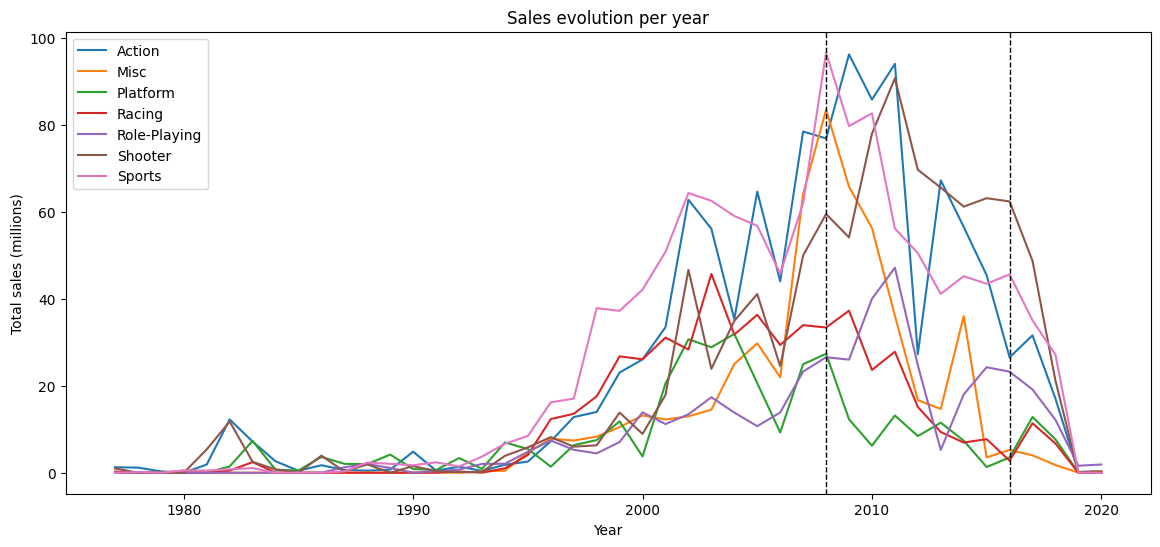

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
year_genre.plot(ax=ax)
ax.set_title("Sales evolution per year")
ax.set_xlabel("Year")
ax.set_ylabel("Total sales (millions)")
ax.axvline(x=2008, color="black", linestyle="--", linewidth=1)
ax.axvline(x=2016, color="black", linestyle="--", linewidth=1)
ax.legend(loc="upper left")

As we can see 2008 was peak, and the fall of the physical copy sales started after 2011.The sharp decline after 2016 does not reflect actual sales, it reflects the industry's shift to digital distribution, which this dataset cannot capture.

Do North America and Japan have different genre taste?

Text(120.58159722222221, 0.5, 'Region')

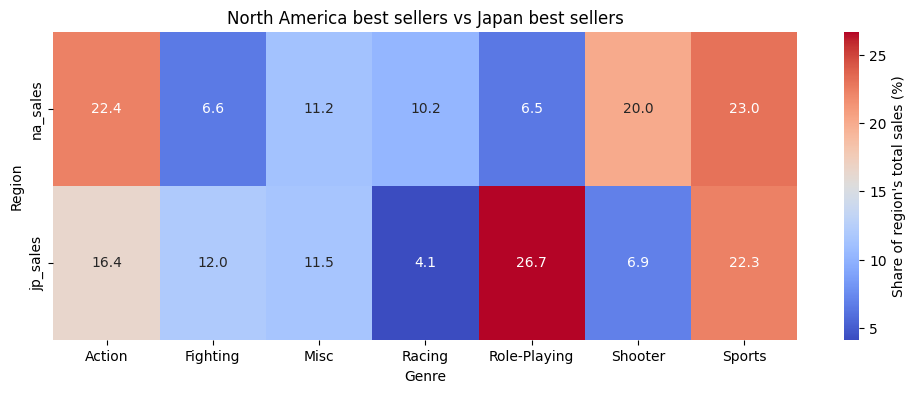

In [ ]:
top_na_genres = games.groupby("genre")["na_sales"].sum().nlargest(5).index
top_jp_genres = games.groupby("genre")["jp_sales"].sum().nlargest(5).index
regional_top = top_na_genres.union(top_jp_genres)

region_genre = games[games["genre"].isin(regional_top)].groupby("genre")[["na_sales", "jp_sales"]].sum()
region_pct = region_genre.div(region_genre.sum()) * 100

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(region_pct.T, annot=True, fmt=".1f", cmap="coolwarm",
            ax=ax, cbar_kws={"label": "Share of region's total sales (%)"})
ax.set_title("North America best sellers vs Japan best sellers")
ax.set_xlabel("Genre")
ax.set_ylabel("Region")


Best sellers in North America and Japan.

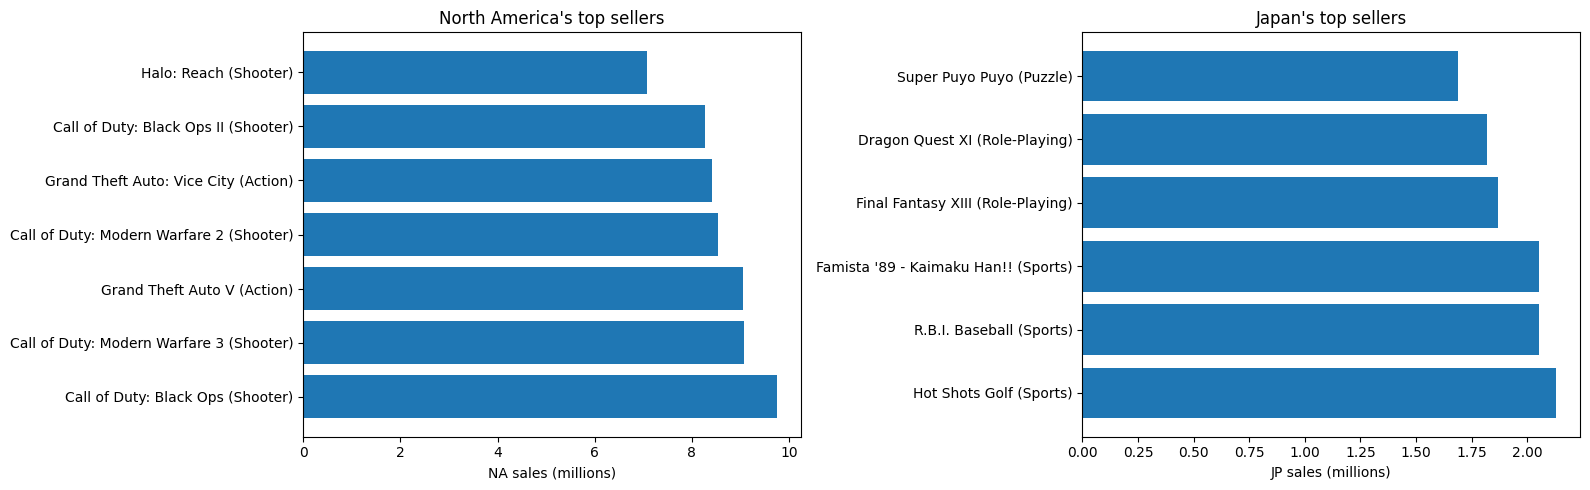

In [ ]:
top_na = games.nlargest(7, "na_sales").copy()
top_na["label"] = top_na["title"] + " (" + top_na["genre"] + ")"

top_jp = games.nlargest(7, "jp_sales").copy()
top_jp["label"] = top_jp["title"] + " (" + top_jp["genre"] + ")"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top_na["label"], top_na["na_sales"])
axes[0].set_title("North America's top sellers")
axes[0].set_xlabel("NA sales (millions)")
axes[0].invert_yaxis()

axes[1].barh(top_jp["label"], top_jp["jp_sales"])
axes[1].set_title("Japan's top sellers")
axes[1].set_xlabel("JP sales (millions)")
axes[1].invert_yaxis()

plt.tight_layout()


The aggregate heatmap shows Japan spends four times more share on role playing than North America. But the individual top sellers tell a different story. Japan's top 3 bestselling titles are sports games, not RPGs. This suggests RPG sales are spread across hundreds of mid-tier titles rather than a few blockbusters.

Does the higher critic score leads to higher sales?

Text(0, 0.5, 'Total sales (millions)')

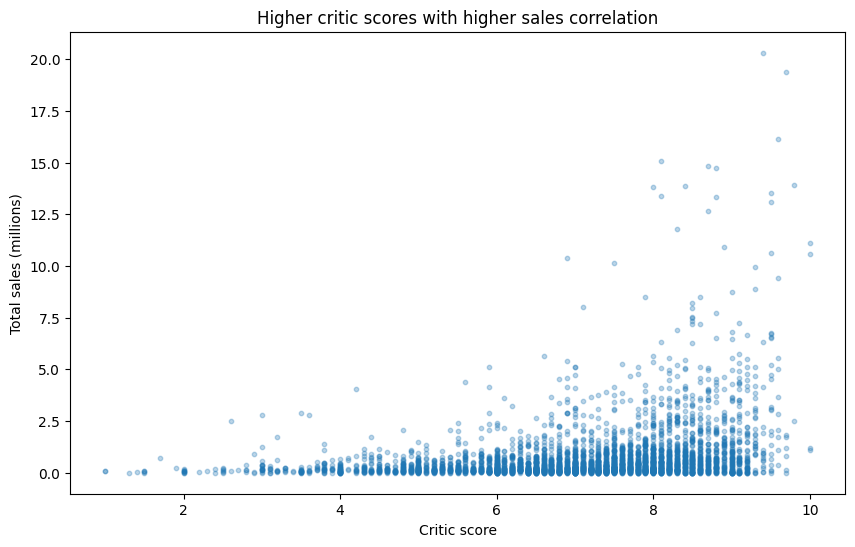

In [ ]:
critic_games = games[games["critic_score"].notna() & games["total_sales"].notna()]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(critic_games["critic_score"], critic_games["total_sales"], alpha=0.3, s=10)
ax.set_title("Higher critic scores with higher sales correlation")
ax.set_xlabel("Critic score")
ax.set_ylabel("Total sales (millions)")


Text(0, 0.5, 'Total sales (millions)')

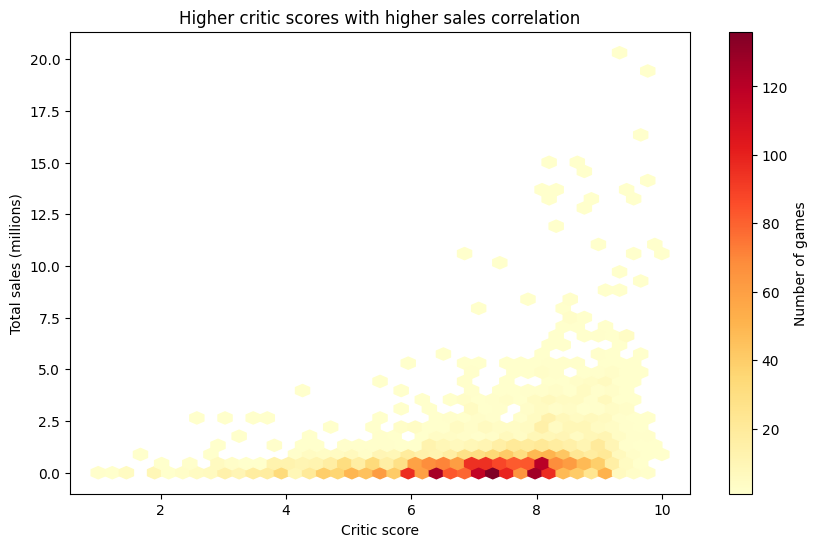

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(critic_games["critic_score"], critic_games["total_sales"],
               gridsize=40, cmap="YlOrRd", mincnt=1)
plt.colorbar(hb, ax=ax, label="Number of games")
ax.set_title("Higher critic scores with higher sales correlation")
ax.set_xlabel("Critic score")
ax.set_ylabel("Total sales (millions)")


Which single game dominates each genre?

In [ ]:
corr = np.corrcoef(critic_games["critic_score"], critic_games["total_sales"])[0, 1]
print(f"Pearson correlation: {corr:.2f}")

Pearson correlation: 0.28


First I tested scatter plot, and according to it sales are really depend on critic scores. But in fact we have a different picture. Hexbin shows clusters of games in between 6-8 score, and those are not even close are best sellers. So we can say that critic scores alone are not commercial success prediction. Which confirms with correlation of 0.28.

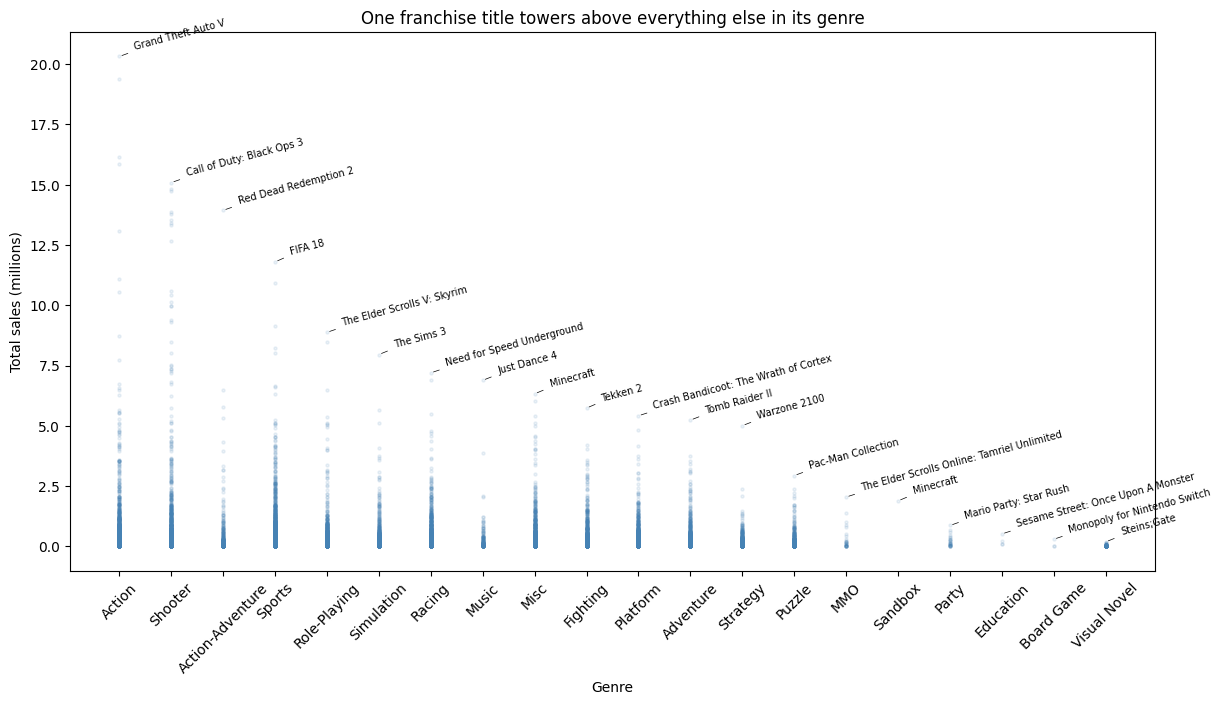

In [ ]:
top_per_genre = games.loc[games.groupby("genre")["total_sales"].idxmax()]

fig, ax = plt.subplots(figsize=(14, 7))
ax.scatter(games["genre"], games["total_sales"], alpha=0.1, s=5, color="steelblue")

for _, row in top_per_genre.iterrows():
    ax.annotate(row["title"],
                xy=(row["genre"], row["total_sales"]),
                xytext=(10, 5), textcoords="offset points",
                fontsize=7, rotation=15,
                arrowprops=dict(arrowstyle="-", color="black", lw=0.5))


ax.set_title("One franchise title towers above everything else in its genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Total sales (millions)")
ax.tick_params(axis="x", rotation=45)


Most cases one single title separates itself from the rest in almost every genre. GTA5 in Actions, CoD Black Ops 3 in Shooters.

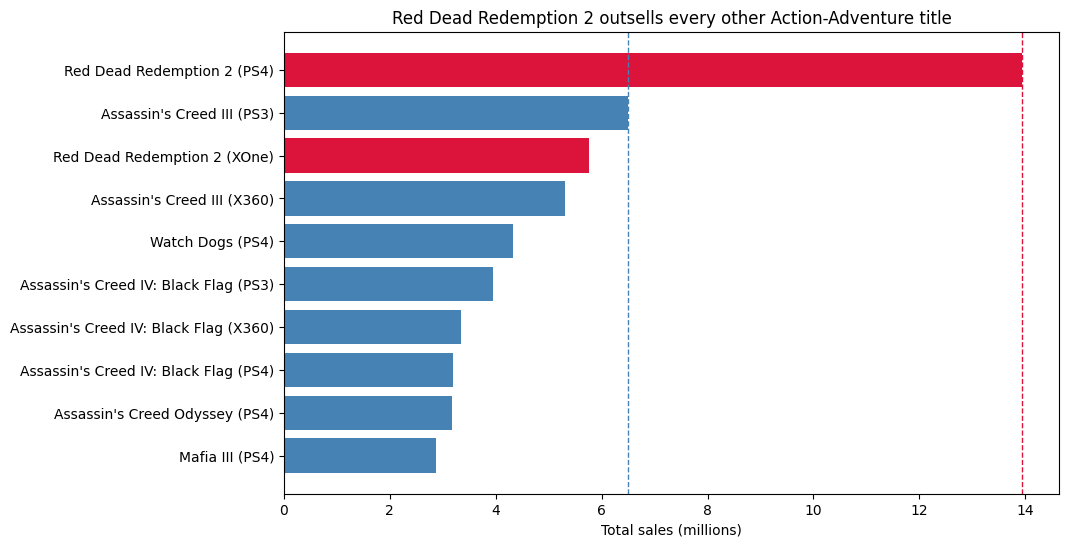

In [ ]:
aa_games = games[games["genre"] == "Action-Adventure"].nlargest(10, "total_sales").copy()
aa_games["label"] = aa_games["title"] + " (" + aa_games["platform"] + ")"

colors = ["crimson" if "Red Dead Redemption 2" in t else "steelblue" for t in aa_games["title"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(aa_games["label"], aa_games["total_sales"], color=colors)
ax.axvline(x=13.94, color="crimson", linestyle="--", linewidth=1)
ax.axvline(x=6.50, color="steelblue", linestyle="--", linewidth=1)
ax.set_title("Red Dead Redemption 2 outsells every other Action-Adventure title")
ax.set_xlabel("Total sales (millions)")
ax.invert_yaxis()

The gap between RDR2 and the second place Assassin's Creed III is larger than the gap between 2nd and 10th.

## Conclusion

### What we found:

- Physical game sales reached top around 2008 and collapsed after 2016
- Genre dominance is not static. Sports ruled the 90s–00s, Shooters took over in the 2010s
- NA and JP have distinct tastes: NA leans Shooter/Action, Japan's aggregate sales favor Role-Playing, but individual top sellers in Japan are Sports and Puzzle titles
- In every genre, one or two franchise titles tower above the rest. Critic scores barely predict which ones

### What we couldn't answer:

- What drove the Sports decline after 2010 — audience fatigue or annual release burnout?
- Do the same outlier dynamics hold in digital-only markets?

### What the data can't show:

- Digital sales — Steam, PSN, mobile are entirely absent
- Indie games — this is a corporate publishing dataset only